# Visualization of Local-Global Surprise

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

In [2]:
results_dir = Path('../../results/local_global_surprise')
dfs = []
for result in results_dir.iterdir():
    corpus_name = result.stem
    df = pl.read_ndjson(result).with_columns(pl.lit(corpus_name).alias('corpus'))
    dfs.append(df)

datasets_enum = pl.Enum(['humicroedit', 'puntuguese'])

# Dataframe has no 'label' column because they are all humorous texts
# They need to be humorous because we need pun and alternative words
# for the metric
df = (pl.concat(dfs, how='diagonal')
        .sort(pl.col('corpus').cast(datasets_enum)))
df

index,location,funniness,interpretation,text,local global surprise,corpus
str,str,f64,str,str,f64,str
"""humicroedit.14530.H""","""twins""",0.2,"""Isis""","""France is ‘ hunting down its c…",-1.0,"""humicroedit"""
"""humicroedit.13034.H""","""bowling""",1.6,"""Syria""","""Pentagon claims 2,000 % increa…",-1.0,"""humicroedit"""
"""humicroedit.8731.H""","""party""",1.0,"""Coalition""","""Iceland PM Calls Snap Vote as …",1.778409,"""humicroedit"""
"""humicroedit.76.H""","""slap""",0.4,"""engage""","""In an apparent first , Iran an…",0.35875,"""humicroedit"""
"""humicroedit.8832.H""","""sounds""",1.2,"""promises""","""All 22 sounds Trump made in hi…",1.236339,"""humicroedit"""
…,…,…,…,…,…,…
"""puntuguese.5.3487.H""","""cruzadinhas""",null,"""cruzadinhas""","""Por que os editores da coquete…",-1.0,"""puntuguese"""
"""puntuguese.5.2441.H""","""spotefy""",null,"""spotify""","""Qual é o pote que toca música?…",0.657822,"""puntuguese"""
"""puntuguese.5.988.H""","""picadeiro""",null,"""picadeiro""","""Qual é o mosquito que pica pal…",-1.0,"""puntuguese"""


## Check null values

In [3]:
(df.filter(pl.col('local global surprise') == -1)
   .group_by('corpus')
   .agg(pl.col('local global surprise').len()))

corpus,local global surprise
str,u64
"""puntuguese""",1332
"""humicroedit""",4233


In [4]:
df = df.filter(pl.col('local global surprise') != -1)
(df.group_by('corpus')
   .agg(pl.col('local global surprise').len()))

corpus,local global surprise
str,u64
"""humicroedit""",10063
"""puntuguese""",1510


## Plots

In [5]:
quantiles = (df.group_by('corpus')
               .agg(pl.col('local global surprise').quantile(0.25).alias('Q1'),
                    pl.col('local global surprise').quantile(0.5).alias('Q2'),
                    pl.col('local global surprise').quantile(0.75).alias('Q3'))
               .with_columns((pl.col('Q3') - pl.col('Q1')).alias('IQR'))
               .with_columns((pl.col('Q1') - 1.5 * pl.col('IQR')).alias('F1'),
                             (pl.col('Q3') + 1.5 * pl.col('IQR')).alias('F2')))
quantiles

corpus,Q1,Q2,Q3,IQR,F1,F2
str,f64,f64,f64,f64,f64,f64
"""puntuguese""",0.757108,0.912641,1.036636,0.279529,0.337815,1.455929
"""humicroedit""",0.623095,0.820175,0.96306,0.339965,0.113148,1.473008


In [6]:
df_with_quantiles = df.join(quantiles, on='corpus')
is_low_outlier = (pl.col('local global surprise') < pl.col('F1'))
is_high_outlier = (pl.col('local global surprise') > pl.col('F2'))
df_no_outliers = df_with_quantiles.filter(~(is_low_outlier | is_high_outlier)).select(df.columns)
df_no_outliers

index,location,funniness,interpretation,text,local global surprise,corpus
str,str,f64,str,str,f64,str
"""humicroedit.76.H""","""slap""",0.4,"""engage""","""In an apparent first , Iran an…",0.35875,"""humicroedit"""
"""humicroedit.8832.H""","""sounds""",1.2,"""promises""","""All 22 sounds Trump made in hi…",1.236339,"""humicroedit"""
"""humicroedit.12174.H""","""laughter""",1.2,"""crimes""","""New DOJ alert system will flag…",0.709626,"""humicroedit"""
"""humicroedit.3731.H""","""morons""",1.0,"""Christians""","""As Someone Who Grew Up Among F…",0.876815,"""humicroedit"""
"""humicroedit.6554.H""","""loonies""",0.2,"""money""","""Canadians may pay more taxes t…",0.79512,"""humicroedit"""
…,…,…,…,…,…,…
"""puntuguese.5.3439.H""","""vem, gansa""",null,"""vingança""","""O ganso chama sua esposa pra a…",1.033562,"""puntuguese"""
"""puntuguese.5.1849.H""","""umbingo""",null,"""umbigo""","""Qual a parte do corpo mais atr…",0.808401,"""puntuguese"""
"""puntuguese.5.57.H""","""cinco""",null,"""circo""","""Por que o quatro estava com um…",1.235071,"""puntuguese"""


### Surprise values without outliers

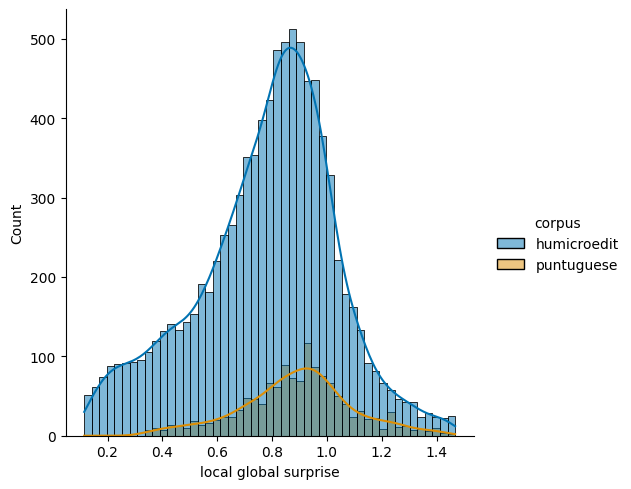

In [7]:
sns.displot(data=df_no_outliers, x='local global surprise',
            hue='corpus', palette='colorblind', kde=True)
plt.savefig('../../results/img/local_global_surprise.pdf')

### Humicroedit Surprise vs. Funniness

In [8]:
df_humicroedit = df_no_outliers.filter(pl.col('corpus') == 'humicroedit')

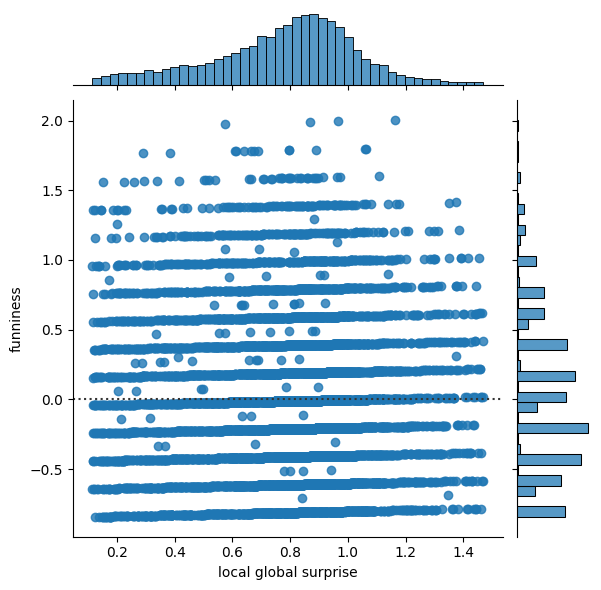

In [9]:
sns.jointplot(data=df_humicroedit, y='funniness', x='local global surprise',
              palette='colorblind', kind='resid')
plt.savefig('../../results/img/humicroedit_surprise_funniness.pdf')

## Statistical tests